<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Quiz9_Fall2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IE7275 – Data Mining in Engineering
### Quiz 9 – Fall 2025

---

This quiz focuses on **model evaluation, cross-validation, hyperparameter tuning, and learning curves** using real-world and synthetic datasets.  

**Instructions:**
- Use Python (scikit-learn, pandas, matplotlib, seaborn, etc.).
- Show code, outputs, and brief interpretations where required.
- Each question should be answered in the cell provided.

---


### Q1
Load the **Breast Cancer dataset** from sklearn. Train a Logistic Regression model and compute accuracy, precision, recall, and F1-score on the test set.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
bc = load_breast_cancer()
X, y = bc.data, bc.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Example pipeline model (students complete training/evaluation below)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# Continue with model training/evaluation here
# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9883040935672515
Precision: 0.9906542056074766
Recall: 0.9906542056074766
F1-score: 0.9906542056074766


### Q2
Plot a confusion matrix for the above classifier predictions and interpret which types of errors are more common.

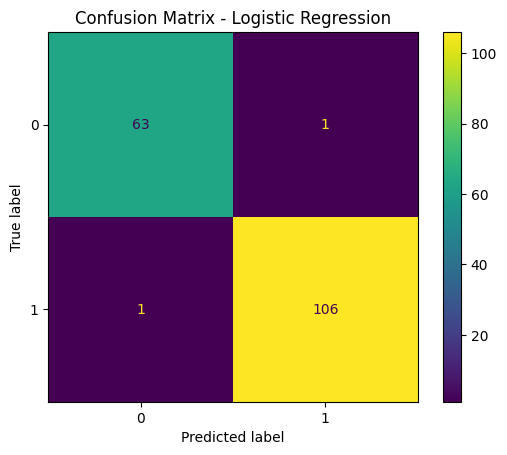

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Continue with model training/evaluation here
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Q3
Perform 5-fold cross-validation with a Decision Tree classifier on the Breast Cancer dataset. Report the mean accuracy and its standard deviation.

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Continue with model training/evaluation here
# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')

# Results
mean_accuracy = np.mean(cv_scores)
std_accuracy = np.std(cv_scores)

print("Cross-validation accuracies:", cv_scores)
print("Mean Accuracy:", mean_accuracy)
print("Standard Deviation:", std_accuracy)

Cross-validation accuracies: [0.9122807  0.90350877 0.92982456 0.95614035 0.88495575]
Mean Accuracy: 0.9173420276354604
Standard Deviation: 0.02419491828674519


### Q4
Manually implement 5-fold cross-validation (without using cross_val_score). Report fold accuracies and average accuracy.

In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Continue with model training/evaluation here
# Initialize model
dt_model = DecisionTreeClassifier(random_state=42)

# KFold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []

# Manual cross-validation
for train_index, test_index in kf.split(X):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Train model
    dt_model.fit(X_train_fold, y_train_fold)

    # Predict
    y_pred_fold = dt_model.predict(X_test_fold)

    # Accuracy
    acc = accuracy_score(y_test_fold, y_pred_fold)
    fold_accuracies.append(acc)

# Results
mean_accuracy = np.mean(fold_accuracies)

print("Fold Accuracies:", fold_accuracies)
print("Average Accuracy:", mean_accuracy)

Fold Accuracies: [0.9473684210526315, 0.9298245614035088, 0.9035087719298246, 0.9473684210526315, 0.9380530973451328]
Average Accuracy: 0.9332246545567457


### Q5
Compare results of regular k-Fold vs Stratified k-Fold cross-validation on the Breast Cancer dataset using Logistic Regression. Explain differences.

In [5]:
from sklearn.model_selection import KFold, StratifiedKFold

# Continue with model training/evaluation here
# Model
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

# --- Regular K-Fold ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = []

for train_idx, test_idx in kf.split(X):
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    model.fit(X_train_fold, y_train_fold)
    y_pred = model.predict(X_test_fold)
    kf_scores.append(accuracy_score(y_test_fold, y_pred))

# --- Stratified K-Fold ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train_fold, X_test_fold = X[train_idx], X[test_idx]
    y_train_fold, y_test_fold = y[train_idx], y[test_idx]

    model.fit(X_train_fold, y_train_fold)
    y_pred = model.predict(X_test_fold)
    skf_scores.append(accuracy_score(y_test_fold, y_pred))

# Results
print("K-Fold Accuracies:", kf_scores)
print("K-Fold Mean:", np.mean(kf_scores))

print("\nStratified K-Fold Accuracies:", skf_scores)
print("Stratified K-Fold Mean:", np.mean(skf_scores))

K-Fold Accuracies: [0.9736842105263158, 0.9824561403508771, 0.9649122807017544, 0.9912280701754386, 0.9734513274336283]
K-Fold Mean: 0.9771464058376029

Stratified K-Fold Accuracies: [0.9736842105263158, 0.9473684210526315, 0.9649122807017544, 0.9912280701754386, 0.9911504424778761]
Stratified K-Fold Mean: 0.9736686849868033


### Q6
Use the **Adult Income dataset** from OpenML. Train a Logistic Regression model and plot the ROC curve. Compute the AUC score.

AUC Score: 0.8315875446779235


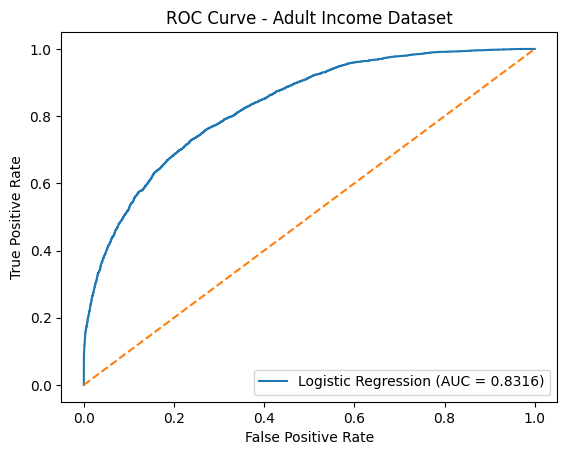

In [6]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import roc_curve, roc_auc_score
adult = fetch_openml('adult', version=2, as_frame=True, parser='auto')
X, y = adult.data, adult.target
X = X.select_dtypes(include=['int64','float64']).fillna(0)
y = (y == '>50K').astype(int)


# Continue with model training/evaluation here
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Model
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# Train
model.fit(X_train, y_train)

# Probabilities (for ROC)
y_probs = model.predict_proba(X_test)[:, 1]

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# AUC score
auc_score = roc_auc_score(y_test, y_probs)

print("AUC Score:", auc_score)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Adult Income Dataset")
plt.legend()
plt.show()

### Q7
On the same dataset, plot the Precision-Recall curve and report the average precision score.

Average Precision Score: 0.6540013350606029


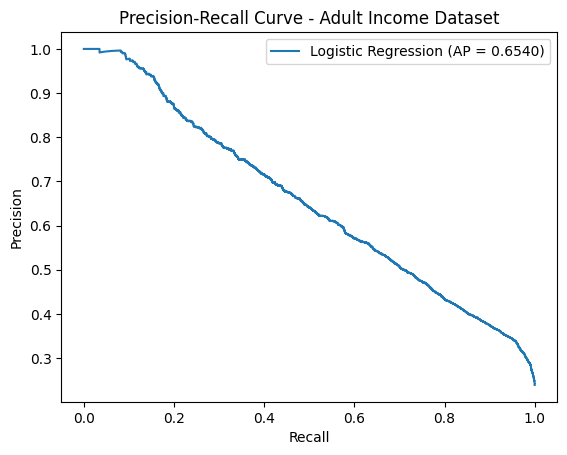

In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Continue with model training/evaluation here
# Use probabilities from the trained model
y_probs = model.predict_proba(X_test)[:, 1]

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Average Precision Score
ap_score = average_precision_score(y_test, y_probs)

print("Average Precision Score:", ap_score)

# Plot Precision-Recall curve
plt.figure()
plt.plot(recall, precision, label=f"Logistic Regression (AP = {ap_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Adult Income Dataset")
plt.legend()
plt.show()

### Q8
Compare ROC curve and Precision-Recall curve for the Adult Income dataset. Which provides more useful insights given class imbalance?

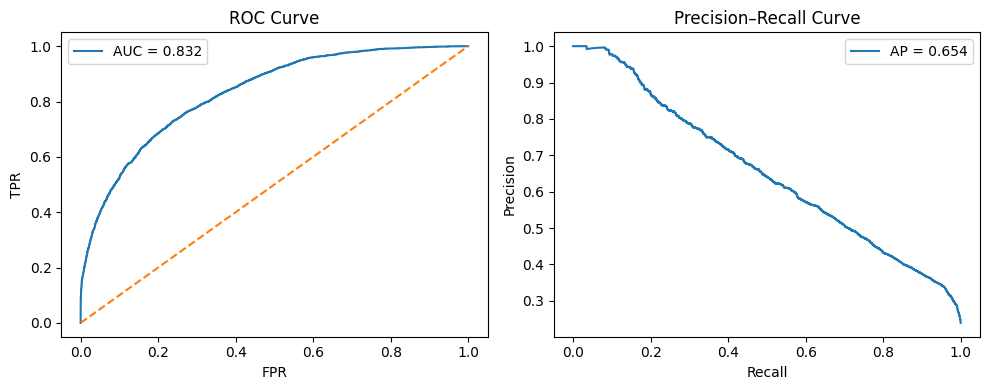

In [8]:
# Continue with ROC/PR
# Continue with model training/evaluation here
# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Model
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# 3. Train
model.fit(X_train, y_train)

# 4. Probabilities (IMPORTANT for ROC/PR)
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# 5. ROC
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

# 6. Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

# 7. Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()


### Q9
Train a Logistic Regression classifier on the Adult Income dataset with class weights to handle imbalance. Compare results with the default model.

In [9]:
# make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced')

# Continue with model training/evaluation here
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# default model
model1 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model1.fit(X_train, y_train)
y_prob1 = model1.predict_proba(X_test)[:, 1]

auc1 = roc_auc_score(y_test, y_prob1)
ap1 = average_precision_score(y_test, y_prob1)

# balanced model
model2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

model2.fit(X_train, y_train)
y_prob2 = model2.predict_proba(X_test)[:, 1]

auc2 = roc_auc_score(y_test, y_prob2)
ap2 = average_precision_score(y_test, y_prob2)

# results
print("default AUC:", auc1)
print("default AP:", ap1)

print("balanced AUC:", auc2)
print("balanced AP:", ap2)

default AUC: 0.8315875446779235
default AP: 0.6540013350606029
balanced AUC: 0.8322666660047998
balanced AP: 0.6505235981032346


### Q10
Adjust the decision threshold for the Logistic Regression classifier. Show how precision and recall change as the threshold varies.

In [10]:
import numpy as np

# Continue with model training/evaluation here
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(X_train, y_train)

# probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# different thresholds
thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print("threshold:", t, "precision:", precision, "recall:", recall)

threshold: 0.1 precision: 0.3449922158796056 recall: 0.9480889903023388
threshold: 0.2 precision: 0.45887151597552683 recall: 0.7701083856246435
threshold: 0.30000000000000004 precision: 0.5619537275064267 recall: 0.623502567027952
threshold: 0.4 precision: 0.6428571428571429 recall: 0.4980034227039361
threshold: 0.5 precision: 0.7212855637513171 recall: 0.3904734740444952
threshold: 0.6 precision: 0.7880844645550528 recall: 0.29806046776953793
threshold: 0.7000000000000001 precision: 0.8392857142857143 recall: 0.22789503707929265
threshold: 0.8 precision: 0.9028400597907325 recall: 0.17227609811751282


### Q11
Use GridSearchCV to tune hyperparameters of an SVM classifier (C and kernel) on the Breast Cancer dataset. Report the best parameters.

In [11]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Load dataset
bc = load_breast_cancer()
X, y = bc.data, bc.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly']
}

# GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Results
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", f"{grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_model = grid_search.best_estimator_
print("Test Accuracy:", f"{best_model.score(X_test_scaled, y_test):.4f}")

Best Parameters: {'C': 0.1, 'kernel': 'linear'}
Best CV Accuracy: 0.9774
Test Accuracy: 0.9708


### Q12
Use RandomizedSearchCV to tune hyperparameters of a Random Forest classifier on the Breast Cancer dataset. Report the best parameters.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Continue with model training/evaluation here
# Load dataset
bc = load_breast_cancer()
X, y = bc.data, bc.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Define hyperparameter distribution
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

# Results
print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", f"{random_search.best_score_:.4f}")

# Evaluate on test set
best_model = random_search.best_estimator_
print("Test Accuracy:", f"{best_model.score(X_test, y_test):.4f}")


Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 5}
Best CV Accuracy: 0.9725
Test Accuracy: 0.9474


### Q13
Visualize the results of Grid Search for SVM parameters (heatmap of accuracy across C and kernel values).

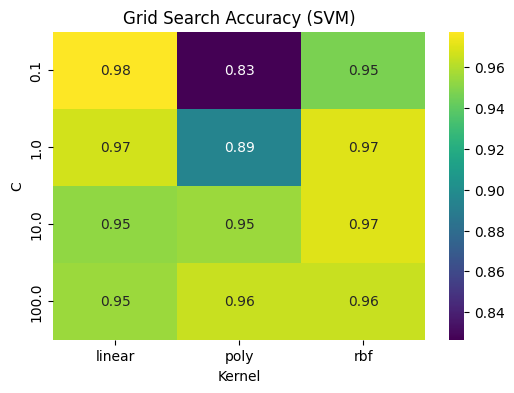

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Continue with model training/evaluation here
# results from grid search
results = grid_search.cv_results_

# convert to dataframe
df = pd.DataFrame(results)

# pivot table for heatmap
heatmap_data = df.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_kernel'
)

# plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data, annot=True, cmap="viridis")
plt.title("Grid Search Accuracy (SVM)")
plt.xlabel("Kernel")
plt.ylabel("C")
plt.show()

### Q14
Perform nested cross-validation with Logistic Regression on the Breast Cancer dataset to estimate unbiased model performance.

In [14]:
from sklearn.model_selection import cross_val_score

# Continue with model training/evaluation here
# Load data
bc = load_breast_cancer()
X, y = bc.data, bc.target

# Model pipeline
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# Outer CV (for unbiased evaluation)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nested CV (no inner tuning here since none is asked)
scores = cross_val_score(model, X, y, cv=outer_cv, scoring='accuracy')

# Results
print("Nested CV Accuracies:", scores)
print("Mean Accuracy:", scores.mean())

Nested CV Accuracies: [0.97368421 0.94736842 0.96491228 0.99122807 0.99115044]
Mean Accuracy: 0.9736686849868033


### Q15
Train multiple classifiers (Logistic Regression, Random Forest, SVM) on the Breast Cancer dataset. Use McNemar's test to compare their performance statistically.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.contingency_tables import mcnemar

# Continue with model training/evaluation here
# Load data
bc = load_breast_cancer()
X, y = bc.data, bc.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Models
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
rf = RandomForestClassifier(random_state=42)
svm = make_pipeline(StandardScaler(), SVC())

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Predictions
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test)

# Accuracy (optional)
print("LR Acc:", accuracy_score(y_test, lr_pred))
print("RF Acc:", accuracy_score(y_test, rf_pred))
print("SVM Acc:", accuracy_score(y_test, svm_pred))

# McNemar's Test Function
def mcnemar_test(y_true, pred1, pred2):
    b = np.sum((pred1 == y_true) & (pred2 != y_true))
    c = np.sum((pred1 != y_true) & (pred2 == y_true))

    table = [[0, b],
             [c, 0]]

    result = mcnemar(table, exact=False, correction=True)
    return result.statistic, result.pvalue

# Pairwise comparisons
print("\nLR vs RF:", mcnemar_test(y_test, lr_pred, rf_pred))
print("LR vs SVM:", mcnemar_test(y_test, lr_pred, svm_pred))
print("RF vs SVM:", mcnemar_test(y_test, rf_pred, svm_pred))

LR Acc: 0.9883040935672515
RF Acc: 0.935672514619883
SVM Acc: 0.9766081871345029

LR vs RF: (np.float64(5.818181818181818), np.float64(0.015861332739773026))
LR vs SVM: (np.float64(0.5), np.float64(0.47950012218695337))
RF vs SVM: (np.float64(3.272727272727273), np.float64(0.070440429272088))


### Q16
Implement bootstrap resampling on the Breast Cancer dataset with a Decision Tree classifier. Estimate the distribution of accuracy scores.

In [16]:
import numpy as np

# Continue with model training/evaluation here
# Load data
bc = load_breast_cancer()
X, y = bc.data, bc.target

# Train/test split (fixed test set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

n_bootstrap = 100
scores = []

for _ in range(n_bootstrap):
    # bootstrap sample from training set
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train[idx]
    y_boot = y_train[idx]

    # train model
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_boot, y_boot)

    # evaluate on fixed test set
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    scores.append(acc)

scores = np.array(scores)

print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())
print("Min:", scores.min())
print("Max:", scores.max())

Mean Accuracy: 0.9154385964912279
Std Dev: 0.019958919541713593
Min: 0.8713450292397661
Max: 0.9532163742690059


### Q17
Evaluate the stability of a Random Forest classifier by training it multiple times with different random seeds. Report variance in accuracy.

In [17]:
seeds = [0, 21, 42, 84, 99]

# Continue with model training/evaluation here
# Load data
bc = load_breast_cancer()
X, y = bc.data, bc.target

seeds = [0, 21, 42, 84, 99]
scores = []

for seed in seeds:
    # split changes each time due to seed
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y
    )

    model = RandomForestClassifier(random_state=seed)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    scores.append(acc)

scores = np.array(scores)

print("Accuracies:", scores)
print("Mean Accuracy:", scores.mean())
print("Variance:", scores.var())
print("Std Dev:", scores.std())

Accuracies: [0.95321637 0.96491228 0.93567251 0.96491228 0.96491228]
Mean Accuracy: 0.9567251461988304
Variance: 0.00013132245819226477
Std Dev: 0.011459601135827755


### Q18
Plot a learning curve for Logistic Regression on the Adult Income dataset. Interpret if more training data would help improve performance.

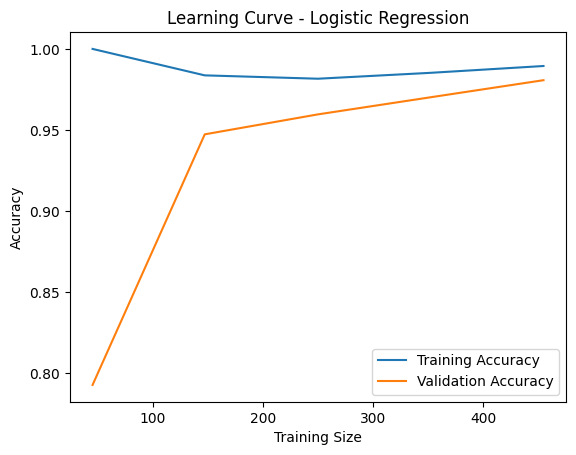

In [18]:
from sklearn.model_selection import learning_curve

# Continue with model training/evaluation here
# Logistic Regression model
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model,
    X, y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# mean + std
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# plot
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Logistic Regression")
plt.legend()
plt.show()

### Q19
Plot a validation curve for the SVM classifier on the Breast Cancer dataset by varying C. Discuss how model complexity affects performance.

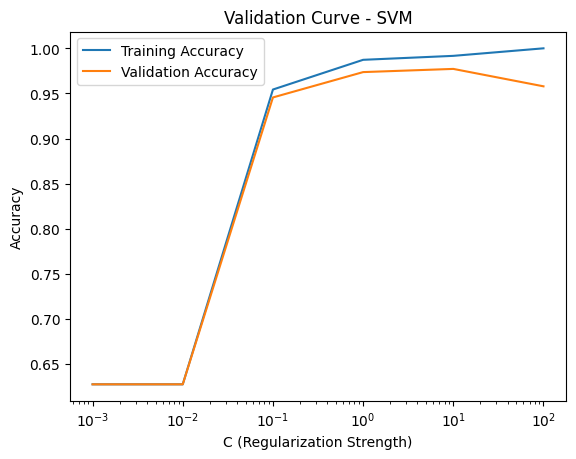

In [19]:
from sklearn.model_selection import validation_curve

# Continue with model training/evaluation here
# model
model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf")
)

# values of C
param_range = np.logspace(-3, 2, 6)

# validation curve
train_scores, test_scores = validation_curve(
    model,
    X, y,
    param_name="svc__C",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# plot
plt.plot(param_range, train_mean, label="Training Accuracy")
plt.plot(param_range, test_mean, label="Validation Accuracy")

plt.xscale("log")
plt.xlabel("C (Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Validation Curve - SVM")
plt.legend()
plt.show()

### Q20
Case Study: **Generate** a synthetic imbalanced dataset. Train a classifier, evaluate using ROC-AUC, Precision-Recall, and confusion matrix.

In [20]:
from sklearn.datasets import make_classification
# Generate synthetic imbalanced dataset if local credit card dataset is not available
X, y = make_classification(n_samples=10000, n_features=20, n_informative=5, n_redundant=2,
                           weights=[0.99], random_state=42)
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix



# Continue with model training/evaluation here
# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# probabilities
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_probs)
print("ROC-AUC:", roc_auc)

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)
print("PR-AUC:", pr_auc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

ROC-AUC: 0.6534141262761994
PR-AUC: 0.06335414988401147
Confusion Matrix:
 [[2953    0]
 [  47    0]]


---